In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

In [3]:
# Check for GPU Support
import lightgbm as lgb

print("LightGBM version:", lgb.__version__)

try:
    test_model = lgb.LGBMClassifier(device="gpu")
    print("✅ GPU is supported")
except Exception as e:
    print("❌ GPU is NOT supported")
    print(e)

LightGBM version: 4.6.0
✅ GPU is supported


In [4]:
# ---------------- CONFIG ----------------
DATASET_PATH = "dataset"
P_SAMPLE_SIZE = 0.1 
RANDOM_SEED = 42
TEST_SIZE_RATIO = 0.2 # train 80% - test 20%

np.random.seed(RANDOM_SEED)

In [5]:
CACHE_FILE = "output/ember_cache.parquet"

def load_cached_ember():
    if os.path.exists(CACHE_FILE):
        print("⚡ Loading from cache...")
        return pd.read_parquet(CACHE_FILE)

    print("⏳ Creating cache...")
    print("⏳ Loading test cache...")
    df_train = pd.read_parquet(os.path.join(DATASET_PATH, 'train_ember_2018_v2_features.parquet'))
    print("✅ Train cache loaded:", df_train.shape)
    
    print("⏳ Loading train cache...")
    df_test = pd.read_parquet(os.path.join(DATASET_PATH, 'test_ember_2018_v2_features.parquet'))
    print("✅ Test cache loaded:", df_test.shape)
 
    print("⏳ Combine train and test df...")
    df = pd.concat([df_train, df_test], ignore_index=True)
    c_uncleaned = df.shape[0]
    print("✅ Combined data before cleaning:", df.shape)
    print("Data shape before cleaning: [0] = benign, [1] = malware, [-1] = unknown" )
    df.to_parquet(f"output/combined_ember_2018_v2_features.parquet", index=False)
    
    print("⏳ Cleaning data, filter data keep only dataset with label 0 and 1 ...")
    df = df[df['Label'].isin([0.0, 1.0])]
    print("✅ Cleaned data:", df.shape)
    c_df_unknown = c_uncleaned - df.shape[0]
    print(f"unknown removed: {c_df_unknown}")
    print(f"Remain samples: {df.shape[0]}")
    
    c_missing = df.isnull().sum();
    print("Missing values: ", c_missing[c_missing > 0])
    print("NA values: ", df.isna().sum().sum())
    print("⏳ Filling NA values ...")
    df = df.fillna(0.0)

    df.to_parquet(CACHE_FILE)
    return df

df = load_cached_ember()
df.to_parquet(f"output/ember_2018_v2_features.parquet", index=False)


⚡ Loading from cache...


In [6]:
SAMPLE_SIZE = P_SAMPLE_SIZE * len(df)
print("⏳ Sampling data into 20000...")
print("1. Group by Label [0, 1]")
print("2. Extract sample with equal distribution from each label by ", SAMPLE_SIZE, " randomly using seed:", RANDOM_SEED)
print("3. Clear index and create new index")
df_sample = df.groupby("Label", group_keys=False).apply(
    lambda x: x.sample(frac=P_SAMPLE_SIZE, random_state=RANDOM_SEED) # RANDOM_SEED = the same randomness every time, this run
).reset_index(drop=True)
print(df_sample['Label'].value_counts())
df_sample.to_parquet(f"output/combined_ember_2018_v2_features_{SAMPLE_SIZE}_samples.parquet", index=False)


X = df_sample.drop(columns=["Label"]) # input that the model take
y = df_sample["Label"].astype(int) # out that the model predict (expected output)


⏳ Sampling data into 20000...
1. Group by Label [0, 1]
2. Extract sample with equal distribution from each label by  79987.6  randomly using seed: 42
3. Clear index and create new index


C:\Users\Senkosal\AppData\Local\Temp\ipykernel_22948\258396507.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby("Label", group_keys=False).apply(


Label
0.0    39998
1.0    39990
Name: count, dtype: int64


In [ ]:
print("⏳ Splitting data into train and test sets ...")
print(" Train 80% - Test 20%")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
) # stratify=y = keep the ratio of label 0 and 1 in both train and test set
print("✅ Train completed:", X_train.shape, y_train.shape)

X_train = X_train.values # convert DataFrame to numpy array
X_test = X_test.values


train_ds = lgb.Dataset(X_train, y_train)
eval_ds = lgb.Dataset(X_test, y_test)

params = {
    "objective": "binary", # binary classification
    "metric": "auc", # use AUC for evaluation
    "learning_rate": 0.05, # slower learning rate for accuracy
    "num_leaves": 500, # leaves of the decision tree, 500 is good for this dataset
    "max_depth": 12, # tree growth depth
    "device": "gpu", # use GPU for training
    "gpu_device_id": 0 # use first GPU
}

model = lgb.train(
    params,
    train_ds,
    valid_sets=[eval_ds],
    callbacks=[lgb.early_stopping(100)]
)

⏳ Splitting data into train and test sets ...
 Train 80% - Test 20%
✅ Train completed: (63990, 2381) (63990,)
[LightGBM] [Info] Number of positive: 31992, number of negative: 31998
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 197394
[LightGBM] [Info] Number of data points in the train set: 63990, number of used features: 2301
[LightGBM] [Info] Using GPU Device: Intel(R) UHD Graphics, Vendor: Intel(R) Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 615 dense feature groups (37.59 MB) transferred to GPU in 0.017350 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499953 -> initscore=-0.000188
[LightGBM] [Info] Start training from score -0.000188
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [War

In [ ]:
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba >= 0.5).astype(int)
print(y_pred_proba)
print(y_pred)

[0.01180152 0.93009841 0.02933922 ... 0.93868659 0.00373473 0.12942122]


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[7651  349]
 [ 348 7650]]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall (Sensitivity):", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Accuracy: 0.9564320540067508
Precision: 0.9563695461932742
Recall (Sensitivity): 0.9564891222805701
F1 Score: 0.9564293304994687


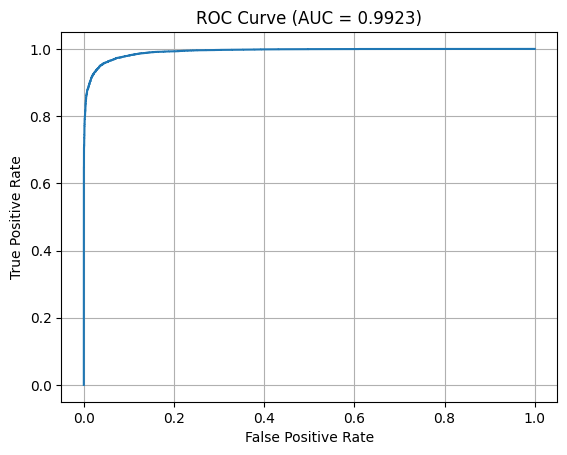

AUC Score: 0.9923106323455865


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.4f})")
plt.grid()
plt.show()

print("AUC Score:", auc_score)


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96      8000
           1       0.96      0.96      0.96      7998

    accuracy                           0.96     15998
   macro avg       0.96      0.96      0.96     15998
weighted avg       0.96      0.96      0.96     15998



In [18]:
model_path = "model/computer_virus_detection_ember_lightGBM.txt"

if not os.path.exists("model"):
    os.makedirs("model")
model.save_model(model_path)